<a href="https://colab.research.google.com/github/ssk-algoverse/sae-binding/blob/main/circuit/Analyse-Circuit-Sebastian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from huggingface_hub import hf_hub_download
from transformer_lens import HookedTransformer, HookedTransformerConfig, utils, ActivationCache
import numpy as np
import pandas as pd
import ast
from torch.utils.data import Dataset, DataLoader
import torch
from functools import partial
import circuitsvis as cv
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import plotly.express as px
import re
import einops
import plotly.graph_objects as go
from jaxtyping import Float, Int
from plotly.subplots import make_subplots
from torch import Tensor
from rich import print as rprint
from rich.table import Column, Table
from IPython.display import HTML, display

# Plotting Utils

In [2]:
def to_numpy(tensor):
    """
    Helper function to convert a tensor to a numpy array. Also works on lists, tuples, and numpy arrays.
    """
    if isinstance(tensor, np.ndarray):
        return tensor
    elif isinstance(tensor, (list, tuple)):
        array = np.array(tensor)
        return array
    elif isinstance(tensor, (torch.Tensor, torch.nn.parameter.Parameter)):
        return tensor.detach().cpu().numpy()
    elif isinstance(tensor, (int, float, bool, str)):
        return np.array(tensor)
    else:
        raise ValueError(f"Input to to_numpy has invalid type: {type(tensor)}")


# ! GENERIC PLOTTING FUNCTIONS

update_layout_set = {
    "xaxis_range",
    "yaxis_range",
    "hovermode",
    "xaxis_title",
    "yaxis_title",
    "colorbar",
    "colorscale",
    "coloraxis",
    "title_x",
    "bargap",
    "bargroupgap",
    "xaxis_tickformat",
    "yaxis_tickformat",
    "title_y",
    "legend_title_text",
    "xaxis_showgrid",
    "xaxis_gridwidth",
    "xaxis_gridcolor",
    "yaxis_showgrid",
    "yaxis_gridwidth",
    "yaxis_gridcolor",
    "showlegend",
    "xaxis_tickmode",
    "yaxis_tickmode",
    "margin",
    "xaxis_visible",
    "yaxis_visible",
    "bargap",
    "bargroupgap",
    "coloraxis_showscale",
    "xaxis_tickangle",
    "yaxis_scaleanchor",
    "xaxis_tickfont",
    "yaxis_tickfont",
}

update_traces_set = {"textposition"}


def imshow(tensor: torch.Tensor, renderer=None, **kwargs):
    kwargs_post = {k: v for k, v in kwargs.items() if k in update_layout_set}
    kwargs_pre = {k: v for k, v in kwargs.items() if k not in update_layout_set}
    if ("size" in kwargs_pre) or ("shape" in kwargs_pre):
        size = kwargs_pre.pop("size", None) or kwargs_pre.pop("shape", None)
        kwargs_pre["height"], kwargs_pre["width"] = size  # type: ignore
    facet_labels = kwargs_pre.pop("facet_labels", None)
    border = kwargs_pre.pop("border", False)
    return_fig = kwargs_pre.pop("return_fig", False)
    text = kwargs_pre.pop("text", None)
    xaxis_tickangle = kwargs_post.pop("xaxis_tickangle", None)
    # xaxis_tickfont = kwargs_post.pop("xaxis_tickangle", None)
    static = kwargs_pre.pop("static", False)
    if "color_continuous_scale" not in kwargs_pre:
        kwargs_pre["color_continuous_scale"] = "RdBu"
    if "color_continuous_midpoint" not in kwargs_pre:
        kwargs_pre["color_continuous_midpoint"] = 0.0
    if "margin" in kwargs_post and isinstance(kwargs_post["margin"], int):
        kwargs_post["margin"] = dict.fromkeys(list("tblr"), kwargs_post["margin"])
    fig = px.imshow(to_numpy(tensor), **kwargs_pre).update_layout(**kwargs_post)
    if facet_labels:
        # Weird thing where facet col wrap means labels are in wrong order
        if "facet_col_wrap" in kwargs_pre:
            facet_labels = reorder_list_in_plotly_way(facet_labels, kwargs_pre["facet_col_wrap"])
        for i, label in enumerate(facet_labels):
            fig.layout.annotations[i]["text"] = label  # type: ignore
    if border:
        fig.update_xaxes(showline=True, linewidth=1, linecolor="black", mirror=True)
        fig.update_yaxes(showline=True, linewidth=1, linecolor="black", mirror=True)
    if text:
        if tensor.ndim == 2:
            # if 2D, then we assume text is a list of lists of strings
            assert isinstance(text[0], list)
            assert isinstance(text[0][0], str)
            text = [text]
        else:
            # if 3D, then text is either repeated for each facet, or different
            assert isinstance(text[0], list)
            if isinstance(text[0][0], str):
                text = [text for _ in range(len(fig.data))]
        for i, _text in enumerate(text):
            fig.data[i].update(text=_text, texttemplate="%{text}", textfont={"size": 12})
    # Very hacky way of fixing the fact that updating layout with xaxis_* only applies to first facet by default
    if xaxis_tickangle is not None:
        n_facets = 1 if tensor.ndim == 2 else tensor.shape[0]
        for i in range(1, 1 + n_facets):
            xaxis_name = "xaxis" if i == 1 else f"xaxis{i}"
            fig.layout[xaxis_name]["tickangle"] = xaxis_tickangle  # type: ignore
    return fig if return_fig else fig.show(renderer=renderer, config={"staticPlot": static})


def reorder_list_in_plotly_way(L: list, col_wrap: int):
    """
    Helper function, because Plotly orders figures in an annoying way when there's column wrap.
    """
    L_new = []
    while len(L) > 0:
        L_new.extend(L[-col_wrap:])
        L = L[:-col_wrap]
    return L_new


def line(y: torch.Tensor | list, renderer=None, **kwargs):
    """
    Edit to this helper function, allowing it to take args in update_layout (e.g. yaxis_range).
    """
    kwargs_post = {k: v for k, v in kwargs.items() if k in update_layout_set}
    kwargs_pre = {k: v for k, v in kwargs.items() if k not in update_layout_set}
    if ("size" in kwargs_pre) or ("shape" in kwargs_pre):
        size = kwargs_pre.pop("size", None) or kwargs_pre.pop("shape", None)
        kwargs_pre["height"], kwargs_pre["width"] = size  # type: ignore
    return_fig = kwargs_pre.pop("return_fig", False)
    if "margin" in kwargs_post and isinstance(kwargs_post["margin"], int):
        kwargs_post["margin"] = dict.fromkeys(list("tblr"), kwargs_post["margin"])
    if "xaxis_tickvals" in kwargs_pre:
        tickvals = kwargs_pre.pop("xaxis_tickvals")
        kwargs_post["xaxis"] = dict(
            tickmode="array",
            tickvals=kwargs_pre.get("x", np.arange(len(tickvals))),
            ticktext=tickvals,
        )
    if "hovermode" not in kwargs_post:
        kwargs_post["hovermode"] = "x unified"
    hovertext = kwargs_pre.pop("hovertext", None)
    if "use_secondary_yaxis" in kwargs_pre and kwargs_pre["use_secondary_yaxis"]:
        del kwargs_pre["use_secondary_yaxis"]
        if "labels" in kwargs_pre:
            labels: dict = kwargs_pre.pop("labels")
            kwargs_post["yaxis_title_text"] = labels.get("y1", None)
            kwargs_post["yaxis2_title_text"] = labels.get("y2", None)
            kwargs_post["xaxis_title_text"] = labels.get("x", None)
        for k in ["title", "template", "width", "height"]:
            if k in kwargs_pre:
                kwargs_post[k] = kwargs_pre.pop(k)
        fig = make_subplots(specs=[[{"secondary_y": True}]]).update_layout(**kwargs_post)
        y0 = to_numpy(y[0])
        y1 = to_numpy(y[1])
        x0, x1 = kwargs_pre.pop("x", [np.arange(len(y0)), np.arange(len(y1))])
        name0, name1 = kwargs_pre.pop("names", ["yaxis1", "yaxis2"])
        fig.add_trace(go.Scatter(y=y0, x=x0, name=name0), secondary_y=False)
        fig.add_trace(go.Scatter(y=y1, x=x1, name=name1), secondary_y=True)
    else:
        y = (
            list(map(to_numpy, y))
            if isinstance(y, list) and not (isinstance(y[0], int) or isinstance(y[0], float))
            else to_numpy(y)
        )  # type: ignore
        names = kwargs_pre.pop("names", None)
        fig = px.line(y=y, **kwargs_pre).update_layout(**kwargs_post)
        if names is not None:
            fig.for_each_trace(lambda trace: trace.update(name=names.pop(0)))
    if hovertext is not None:
        ht = fig.data[0].hovertemplate
        fig.for_each_trace(lambda trace: trace.update(hovertext=hovertext, hovertemplate="%{hovertext}<br>" + ht))

    return fig if return_fig else fig.show(renderer=renderer)


def scatter(x, y, renderer=None, **kwargs):
    x = to_numpy(x)
    y = to_numpy(y)
    add_line = None
    if "add_line" in kwargs:
        add_line = kwargs.pop("add_line")
    kwargs_post = {k: v for k, v in kwargs.items() if k in update_layout_set}
    kwargs_traces = {k: v for k, v in kwargs.items() if k in update_traces_set}
    kwargs_pre = {k: v for k, v in kwargs.items() if k not in (update_layout_set | update_traces_set)}
    if ("size" in kwargs_pre) or ("shape" in kwargs_pre):
        size = kwargs_pre.pop("size", None) or kwargs_pre.pop("shape", None)
        kwargs_pre["height"], kwargs_pre["width"] = size  # type: ignore
    return_fig = kwargs_pre.pop("return_fig", False)
    facet_labels = kwargs_pre.pop("facet_labels", None)
    if "margin" in kwargs_post and isinstance(kwargs_post["margin"], int):
        kwargs_post["margin"] = dict.fromkeys(list("tblr"), kwargs_post["margin"])
    fig = px.scatter(y=y, x=x, **kwargs_pre).update_layout(**kwargs_post)
    if add_line is not None:
        xrange = fig.layout.xaxis.range or [x.min(), x.max()]  # type: ignore
        yrange = fig.layout.yaxis.range or [y.min(), y.max()]  # type: ignore
        add_line = add_line.replace(" ", "")
        if add_line in ["x=y", "y=x"]:
            fig.add_trace(go.Scatter(mode="lines", x=xrange, y=xrange, showlegend=False))
        elif re.match("(x|y)=", add_line):
            try:
                c = float(add_line.split("=")[1])
            except:
                raise ValueError(
                    f"Unrecognized add_line: {add_line}. Please use either 'x=y' or 'x=c' or 'y=c' for some float c."
                )
            x, y = ([c, c], yrange) if add_line[0] == "x" else (xrange, [c, c])
            fig.add_trace(go.Scatter(mode="lines", x=x, y=y, showlegend=False))
        else:
            raise ValueError(
                f"Unrecognized add_line: {add_line}. Please use either 'x=y' or 'x=c' or 'y=c' for some float c."
            )
    if facet_labels:
        for i, label in enumerate(facet_labels):
            fig.layout.annotations[i]["text"] = label  # type: ignore
    fig.update_traces(**kwargs_traces)
    return fig if return_fig else fig.show(renderer=renderer)


def bar(tensor, renderer=None, **kwargs):
    """ """
    if isinstance(tensor, list):
        if isinstance(tensor[0], torch.Tensor):
            arr = [to_numpy(tn) for tn in tensor]
        elif isinstance(tensor[0], list):
            arr = [np.array(tn) for tn in tensor]
        else:
            arr = np.array(tensor)
    else:
        arr = to_numpy(tensor)
    kwargs_post = {k: v for k, v in kwargs.items() if k in update_layout_set}
    kwargs_pre = {k: v for k, v in kwargs.items() if k not in update_layout_set}
    return_fig = kwargs_pre.pop("return_fig", False)
    names = kwargs_pre.pop("names", None)
    if "hovermode" not in kwargs_post:
        kwargs_post["hovermode"] = "x unified"
    if "margin" in kwargs_post and isinstance(kwargs_post["margin"], int):
        kwargs_post["margin"] = dict.fromkeys(list("tblr"), kwargs_post["margin"])
    fig = px.bar(y=arr, **kwargs_pre).update_layout(**kwargs_post)
    if names is not None:
        for i in range(len(fig.data)):
            fig.data[i]["name"] = names[i // 2 if "marginal" in kwargs_pre else i]
    return fig if return_fig else fig.show(renderer=renderer)


def hist(tensor, renderer=None, **kwargs):
    kwargs_post = {k: v for k, v in kwargs.items() if k in update_layout_set}
    kwargs_pre = {k: v for k, v in kwargs.items() if k not in update_layout_set}
    # draw = kwargs_pre.pop("draw", True)
    # static = kwargs_pre.pop("static", False)
    return_fig = kwargs_pre.pop("return_fig", False)
    if isinstance(tensor, list):
        if isinstance(tensor[0], torch.Tensor):
            arr = [to_numpy(tn) for tn in tensor]
        elif isinstance(tensor[0], list):
            arr = [np.array(tn) for tn in tensor]
        else:
            arr = np.array(tensor)
    else:
        arr = to_numpy(tensor)
    if "modebar_add" not in kwargs_post:
        kwargs_post["modebar_add"] = [
            "drawline",
            "drawopenpath",
            "drawclosedpath",
            "drawcircle",
            "drawrect",
            "eraseshape",
        ]
    add_mean_line = kwargs_pre.pop("add_mean_line", False)
    names = kwargs_pre.pop("names", None)
    if "barmode" not in kwargs_post:
        kwargs_post["barmode"] = "overlay"
    if "bargap" not in kwargs_post:
        kwargs_post["bargap"] = 0.0
    if "margin" in kwargs_post and isinstance(kwargs_post["margin"], int):
        kwargs_post["margin"] = dict.fromkeys(list("tblr"), kwargs_post["margin"])
    if "hovermode" not in kwargs_post:
        kwargs_post["hovermode"] = "x unified"
    if "autosize" not in kwargs_post:
        kwargs_post["autosize"] = False

    # If `arr` has a list of arrays, then just doing px.histogram doesn't work annoyingly enough
    # This is janky, even for my functions!
    if isinstance(arr, list) and isinstance(arr[0], np.ndarray):
        assert "marginal" not in kwargs_pre, "Can't use `marginal` with a list of arrays"
        for thing_to_move_from_pre_to_post in ["title", "template", "height", "width", "labels"]:
            if thing_to_move_from_pre_to_post in kwargs_pre:
                kwargs_post[thing_to_move_from_pre_to_post] = kwargs_pre.pop(thing_to_move_from_pre_to_post)
        if "labels" in kwargs_post:
            kwargs_post["xaxis_title_text"] = kwargs_post["labels"].get("x", "")
            kwargs_post["yaxis_title_text"] = kwargs_post["labels"].get("y", "")
            del kwargs_post["labels"]
        fig = go.Figure(layout=go.Layout(**kwargs_post))
        if "nbins" in kwargs_pre:
            kwargs_pre["nbinsx"] = int(kwargs_pre.pop("nbins"))
        for x in arr:
            fig.add_trace(go.Histogram(x=x, name=names.pop(0) if names is not None else None, **kwargs_pre))
    else:
        fig = px.histogram(x=arr, **kwargs_pre).update_layout(**kwargs_post)
        if names is not None:
            for i in range(len(fig.data)):
                fig.data[i]["name"] = names[i // 2 if "marginal" in kwargs_pre else i]

    assert isinstance(arr, (np.ndarray, Tensor))

    if add_mean_line:
        if arr.ndim == 1:
            fig.add_vline(
                x=arr.mean(),
                line_width=3,
                line_dash="dash",
                line_color="black",
                annotation_text=f"Mean = {arr.mean():.3f}",
                annotation_position="top",
            )
        elif arr.ndim == 2:
            for i in range(arr.shape[0]):
                fig.add_vline(
                    x=arr[i].mean(),
                    line_width=3,
                    line_dash="dash",
                    line_color="black",
                    annotation_text=f"Mean = {arr.mean():.3f}",
                    annotation_position="top",
                )
    return fig if return_fig else fig.show(renderer=renderer)


# ! PLOTTING FUNCTIONS FOR PART 2: INTRO TO MECH INTERP


def plot_comp_scores(
    model, comp_scores, title: str = "", baseline: torch.Tensor | None = None, filename: str | None = None
):
    fig = px.imshow(
        to_numpy(comp_scores),
        y=[f"L0H{h}" for h in range(model.cfg.n_heads)],
        x=[f"L1H{h}" for h in range(model.cfg.n_heads)],
        labels={"x": "Layer 1", "y": "Layer 0"},
        title=title,
        color_continuous_scale="RdBu" if baseline is not None else "Blues",
        color_continuous_midpoint=baseline if baseline is not None else None,
        zmin=None if baseline is not None else 0.0,
        width=550,
        height=450,
    )
    fig.show()
    if filename is not None:
        fig.write_html(filename)


def convert_tokens_to_string(model, tokens, batch_index=0):
    """
    Helper function to convert tokens into a list of strings, for printing.
    """
    if len(tokens.shape) == 2:
        tokens = tokens[batch_index]
    return [f"|{model.tokenizer.decode(tok)}|_{c}" for (c, tok) in enumerate(tokens)]


def plot_logit_attribution(model, logit_attr: torch.Tensor, tokens: torch.Tensor, title: str = "", filename: str | None = None):
    tokens = tokens.squeeze()
    y_labels = convert_tokens_to_string(model, tokens[:-1])
    x_labels = ["Direct"] + [f"L{l}H{h}" for l in range(model.cfg.n_layers) for h in range(model.cfg.n_heads)]
    fig = imshow(
        to_numpy(logit_attr),  # type: ignore
        x=x_labels,
        y=y_labels,
        labels={"x": "Term", "y": "Position", "color": "logit"},
        title=title if title else None,
        height=100 + (30 if title else 0) + 15 * len(y_labels),
        width=24 * len(x_labels),
        return_fig=True,
    )
    fig.show()
    if filename is not None:
        fig.write_html(filename)


# ! PLOTTING FUNCTIONS FOR PART 4: BALANCED BRACKET CLASSIFICATION

color_discrete_map = dict(
    zip(
        ["both failures", "just neg failure", "balanced", "just total elevation failure"],
        px.colors.qualitative.D3,
    )
)
# names = ["balanced", "just total elevation failure", "just neg failure", "both failures"]
# colors = ['#2CA02C', '#1c96eb', '#b300ff', '#ff4800']
# color_discrete_map = dict(zip(names, colors))


def plot_failure_types_scatter(
    unbalanced_component_1: Float[Tensor, "batch"],
    unbalanced_component_2: Float[Tensor, "batch"],
    failure_types_dict: dict[str, Float[Tensor, "batch"]],
    data,
    filename: str | None = None,
):
    failure_types = np.full(len(unbalanced_component_1), "", dtype=np.dtype("U32"))
    for name, mask in failure_types_dict.items():
        failure_types = np.where(to_numpy(mask), name, failure_types)
    failures_df = pd.DataFrame(
        {
            "Head 2.0 contribution": to_numpy(unbalanced_component_1),
            "Head 2.1 contribution": to_numpy(unbalanced_component_2),
            "Failure type": to_numpy(failure_types),
        }
    )[data.starts_open.tolist()]
    fig = px.scatter(
        failures_df,
        color_discrete_map=color_discrete_map,
        x="Head 2.0 contribution",
        y="Head 2.1 contribution",
        color="Failure type",
        title="h20 vs h21 for different failure types",
        template="simple_white",
        height=600,
        width=800,
        # category_orders={"color": failure_types_dict.keys()},
    ).update_traces(marker_size=4)
    fig.show()
    if filename is not None:
        fig.write_html(filename)


def plot_contribution_vs_open_proportion(
    unbalanced_component: Float[Tensor, "batch"],
    title: str,
    failure_types_dict: dict,
    data,
    filename: str | None = None,
):
    failure_types = np.full(len(unbalanced_component), "", dtype=np.dtype("U32"))
    for name, mask in failure_types_dict.items():
        failure_types = np.where(to_numpy(mask), name, failure_types)
    fig = (
        px.scatter(
            x=to_numpy(data.open_proportion),
            y=to_numpy(unbalanced_component),
            color=failure_types,
            color_discrete_map=color_discrete_map,
            title=title,
            template="simple_white",
            height=500,
            width=800,
            labels={"x": "Open-proportion", "y": "Head contribution"},
        )
        .update_traces(marker_size=4, opacity=0.5)
        .update_layout(legend_title_text="Failure type")
    )
    fig.show()
    if filename is not None:
        fig.write_html(filename)


def mlp_attribution_scatter(
    out_by_component_in_pre_20_unbalanced_dir: Float[Tensor, "comp batch"],
    data,
    failure_types_dict: dict,
    filenames: list[str] | None = None,
) -> None:
    failure_types = np.full(out_by_component_in_pre_20_unbalanced_dir.shape[-1], "", dtype=np.dtype("U32"))
    for name, mask in failure_types_dict.items():
        failure_types = np.where(to_numpy(mask), name, failure_types)
    for layer in range(2):
        mlp_output = out_by_component_in_pre_20_unbalanced_dir[3 + layer * 3]
        fig = (
            px.scatter(
                x=to_numpy(data.open_proportion[data.starts_open]),
                y=to_numpy(mlp_output[data.starts_open]),
                color_discrete_map=color_discrete_map,
                color=to_numpy(failure_types)[to_numpy(data.starts_open)],
                title=f"Amount MLP {layer} writes in unbalanced direction for Head 2.0",
                template="simple_white",
                height=500,
                width=800,
                labels={"x": "Open-proportion", "y": "Head 2.0 contribution"},
            )
            .update_traces(marker_size=4, opacity=0.5)
            .update_layout(legend_title_text="Failure type")
        )
        fig.show()
        if filenames is not None:
            assert len(filenames) == 2
            fig.write_html(filenames[layer])


def plot_neurons(
    neurons_in_unbalanced_dir: Float[Tensor, "batch neurons"],
    model,
    data,
    failure_types_dict: dict,
    layer: int,
    renderer=None,
    filename: str | None = None,
):
    failure_types = np.full(neurons_in_unbalanced_dir.shape[0], "", dtype=np.dtype("U32"))
    for name, mask in failure_types_dict.items():
        failure_types = np.where(to_numpy(mask[to_numpy(data.starts_open)]), name, failure_types)

    # Get data that can be turned into a dataframe (plotly express is sometimes easier to use with a dataframe)
    # Plot a scatter plot of all the neuron contributions, color-coded according to failure type, with slider to view neurons
    neuron_numbers = einops.repeat(t.arange(model.cfg.d_model), "n -> (s n)", s=data.starts_open.sum())
    failure_types = einops.repeat(failure_types, "s -> (s n)", n=model.cfg.d_model)
    data_open_proportion = einops.repeat(data.open_proportion[data.starts_open], "s -> (s n)", n=model.cfg.d_model)
    df = pd.DataFrame(
        {
            "Output in 2.0 direction": to_numpy(neurons_in_unbalanced_dir.flatten()),
            "Neuron number": to_numpy(neuron_numbers),
            "Open-proportion": to_numpy(data_open_proportion),
            "Failure type": failure_types,
        }
    )
    fig = (
        px.scatter(
            df,
            x="Open-proportion",
            y="Output in 2.0 direction",
            color="Failure type",
            animation_frame="Neuron number",
            title=f"Neuron contributions from layer {layer}",
            template="simple_white",
            height=800,
            width=1100,
        )
        .update_traces(marker_size=3)
        .update_layout(xaxis_range=[0, 1], yaxis_range=[-5, 5])
    )
    fig.show(renderer=renderer)
    if filename is not None:
        fig.write_html(filename)


def plot_attn_pattern(pattern: Float[Tensor, "batch head_idx seqQ seqK"], filename: str | None = None):
    fig = px.imshow(
        pattern,
        title="Estimate for avg attn probabilities when query is from '('",
        labels={
            "x": "Key tokens (avg of left & right parens)",
            "y": "Query tokens (all left parens)",
        },
        height=900,
        width=900,
        color_continuous_scale="RdBu_r",
        range_color=[0, pattern.max().item()],
    ).update_layout(
        xaxis=dict(
            tickmode="array",
            ticktext=["[start]", *[f"{i+1}" for i in range(40)], "[end]"],
            tickvals=list(range(42)),
            tickangle=0,
        ),
        yaxis=dict(
            tickmode="array",
            ticktext=["[start]", *[f"{i+1}" for i in range(40)], "[end]"],
            tickvals=list(range(42)),
        ),
    )
    fig.show()
    if filename is not None:
        fig.write_html(filename)


def hists_per_comp(
    out_by_component_in_unbalanced_dir: Float[Tensor, "component batch"],
    data,
    xaxis_range=(-1, 1),
    filename: str | None = None,
):
    """
    Plots the contributions in the unbalanced direction, as supplied by the `out_by_component_in_unbalanced_dir` tensor.
    """
    titles = {
        (1, 1): "embeddings",
        (2, 1): "head 0.0",
        (2, 2): "head 0.1",
        (2, 3): "mlp 0",
        (3, 1): "head `1.0`",
        (3, 2): "head `1.1`",
        (3, 3): "mlp 1",
        (4, 1): "head 2.0",
        (4, 2): "head 2.1",
        (4, 3): "mlp 2",
    }
    n_layers = out_by_component_in_unbalanced_dir.shape[0] // 3
    fig = make_subplots(rows=n_layers + 1, cols=3)
    for ((row, col), title), in_dir in zip(titles.items(), out_by_component_in_unbalanced_dir):
        fig.add_trace(
            go.Histogram(
                x=to_numpy(in_dir[data.isbal]),
                name="Balanced",
                marker_color="blue",
                opacity=0.5,
                legendgroup="1",
                showlegend=title == "embeddings",
            ),
            row=row,
            col=col,
        )
        fig.add_trace(
            go.Histogram(
                x=to_numpy(in_dir[~data.isbal]),
                name="Unbalanced",
                marker_color="red",
                opacity=0.5,
                legendgroup="2",
                showlegend=title == "embeddings",
            ),
            row=row,
            col=col,
        )
        fig.update_xaxes(title_text=title, row=row, col=col, range=xaxis_range)
    fig.update_layout(
        width=1200,
        height=250 * (n_layers + 1),
        barmode="overlay",
        legend=dict(yanchor="top", y=0.92, xanchor="left", x=0.4),
        title="Histograms of component significance",
    )
    fig.show()
    if filename is not None:
        fig.write_html(filename)


def plot_loss_difference(log_probs, rep_str, seq_len, filename: str | None = None):
    fig = px.line(
        to_numpy(log_probs),
        hover_name=rep_str[1:],
        title=f"Per token log prob on correct token, for sequence of length {seq_len}*2 (repeated twice)",
        labels={"index": "Sequence position", "value": "Log prob"},
    ).update_layout(showlegend=False, hovermode="x unified")
    fig.add_vrect(x0=0, x1=seq_len - 0.5, fillcolor="red", opacity=0.2, line_width=0)
    fig.add_vrect(x0=seq_len - 0.5, x1=2 * seq_len - 1, fillcolor="green", opacity=0.2, line_width=0)
    fig.show()
    if filename is not None:
        fig.write_html(filename)


# Setup

In [3]:
from huggingface_hub import hf_hub_download

REPO_ID = "sebastianhoenig/2L2H_Final"
FILENAME = "D256_L2_H2_attnOnly1_lr5.0e-04_wd0.01.pt"

weights_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

In [4]:
REPO_ID = "sojup/entity_binding_test"
FILENAME = "id_to_entity.csv"

id_mapping_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

In [5]:
E = 100
T = 10
D_VOCAB = E + T + 3
N_LAYERS = 2
HEADS = 2
d_model = 256
n_ctx   = 64

def build_model(n_layers: int, n_heads: int) -> HookedTransformer:
    if d_model % n_heads != 0:
        return None
    d_head = d_model // n_heads

    cfg = HookedTransformerConfig(
        n_layers=n_layers,
        n_heads=n_heads,
        d_model=d_model,
        d_head=d_head,
        n_ctx=n_ctx,
        d_vocab=D_VOCAB,
        d_vocab_out=E,
        attn_only=True,
        normalization_type="LN",
        positional_embedding_type="rotary",
    )
    return HookedTransformer(cfg)

model = build_model(N_LAYERS, HEADS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Load the model
pretrained_weights = torch.load(weights_path, map_location=device, weights_only=True)
state_dict = pretrained_weights["model"]
model.load_state_dict(state_dict)

print("Model loaded successfully.")

# need this for attention patching later
model.cfg.use_attn_result = True

Moving model to device:  cpu
Model loaded successfully.


In [6]:
id_mapping_df = pd.read_csv(id_mapping_path)
id_to_entity = dict(zip(id_mapping_df['id'], id_mapping_df['name']))

In [7]:
id_to_entity[100] = 'loves'
id_to_entity[101] = 'works with'
id_to_entity[102] = 'interacts with'
id_to_entity[103] = 'lives with'
id_to_entity[104] = 'has a grudge against'
id_to_entity[105] = 'is interested in'
id_to_entity[106] = 'plays with'
id_to_entity[107] = 'goes to school with'
id_to_entity[108] = 'is jealous of'
id_to_entity[109] = 'wants'

In [8]:
id_to_entity_rev = {v: k for k, v in id_to_entity.items()}

In [9]:
class EntityBindingDataset(Dataset):
    def __init__(self, dataframe, parse_tokens_if_str=True):
        self.df = dataframe.reset_index(drop=True)
        self.parse_tokens_if_str = parse_tokens_if_str

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        seq = row["tokens"]
        tokens = torch.tensor(seq, dtype=torch.long)
        label  = torch.tensor(int(row["label"]), dtype=torch.long)
        return tokens, label

In [10]:
from datasets import load_dataset

dataset = load_dataset("sojup/entity_binding", split="test")

In [11]:
test_df = dataset.to_pandas()
test_dataset = EntityBindingDataset(test_df)

In [12]:
example, label = test_dataset[0]
example, label, [id_to_entity[i.item()] for i in example], id_to_entity[label.item()]

(tensor([ 10, 104,   1, 110,  20, 103,  30, 110,  70, 105,  37, 110,  30, 100,
          24, 110, 105,  70, 111]),
 tensor(37),
 ['Jeffery',
  'has a grudge against',
  'Angel',
  ',',
  'Linda',
  'lives with',
  'Lindsay',
  ',',
  'Jason',
  'is interested in',
  'Christine',
  ',',
  'Lindsay',
  'loves',
  'Susan',
  ',',
  'is interested in',
  'Jason',
  '?'],
 'Christine')

  0%|          | 0/1 [00:00<?, ?it/s]

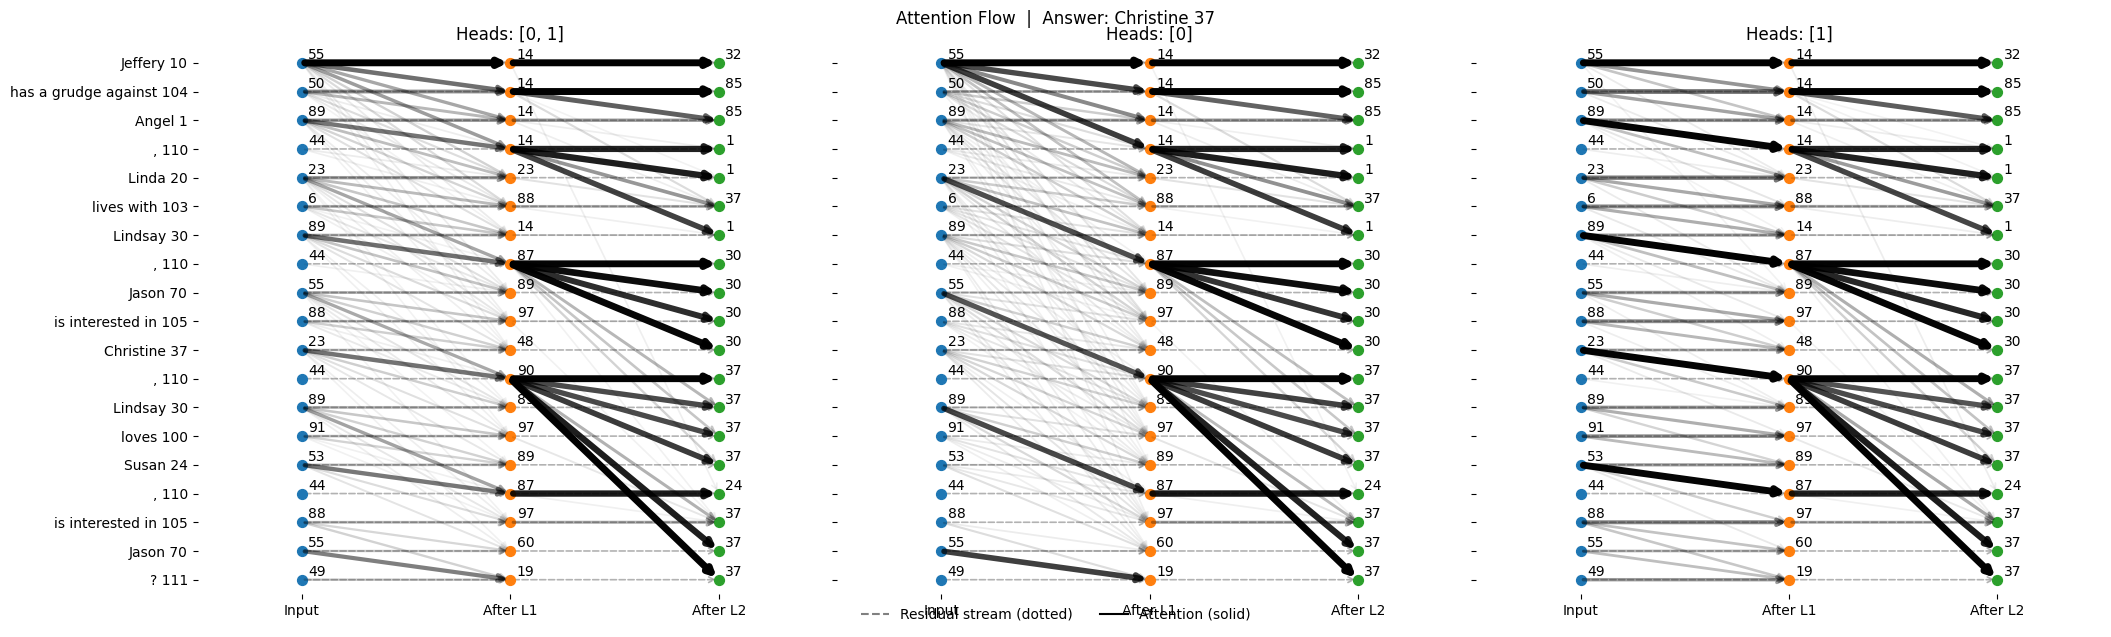

In [ ]:
from matplotlib.lines import Line2D


@torch.no_grad()
def compute_nonimpactful_attention_positions(model, toks, device="cpu", verbose=False):
    """
    Returns a boolean tensor mask of shape [n_layers, n_heads, seq_len]
    where True = *impactful* (keep) and False = *non-impactful* (safe to ablate).

    The test is done wrt the *original* baseline prediction (no ablations).
    """
    model.eval()
    toks_b = toks.unsqueeze(0).to(device)  # [1, seq_len]
    n_layers = model.cfg.n_layers
    n_heads = model.cfg.n_heads
    seq_len = toks_b.shape[-1]

    # Baseline top-1 prediction at last token
    base_logits = model(toks_b, return_type="logits")[0, -1]

    loss = torch.zeros(n_layers, n_heads, seq_len, seq_len, device=device)

    for l in range(n_layers):
        for h in range(n_heads):
            for q_pos in range(seq_len):
                for k_pos in range(seq_len):
                    def ablate_one_key(pat, hook, head_idx=h, query_idx=q_pos, key_idx=k_pos):
                        pat[:, head_idx, query_idx, key_idx] = 0.0
                        return pat

                    logits = model.run_with_hooks(
                        toks_b,
                        return_type="logits",
                        fwd_hooks=[(f"blocks.{l}.attn.hook_pattern", ablate_one_key)],
                    )

                    loss[l, h, q_pos, k_pos] = (logits[0, -1] - base_logits).abs().sum() 

    return loss.detach().cpu()


def make_position_ablation_hooks(keep_mask, device="cpu"):
    """
    keep_mask: Bool tensor [n_layers, n_heads, seq_len], True=keep, False=ablate.
    Returns a list of (hook_name, hook_fn) you can pass to run_with_hooks/run_with_cache.
    """
    keep_mask = torch.as_tensor(keep_mask, dtype=torch.bool, device=device)
    hooks = []

    for l in range(model.cfg.n_layers):

        def hook_layer(pat, hook, l_idx=l):
            pat = pat * keep_mask[l_idx].unsqueeze(0).cpu()
            return pat

        hooks.append((f"blocks.{l}.attn.hook_pattern", hook_layer))

    return hooks


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- UPDATED: now takes ax/cache/position_tokens and can skip showing ---
def plot_attention_flow(
    model,
    toks,
    device,
    position_names=None,
    threshold=0.05,
    answer=None,
    fwd_hooks=[],
    heads=[0, 1],
    *,
    ax=None,
    cache=None,
    position_tokens=None,
    draw_token_text=True,
    add_legend=True,
    show=True,
):
    """
    Plots the attention flow across layers for a single input sequence.

    New args:
      ax: draw on this axis (if None, a new fig/ax is created)
      cache: optional precomputed cache from run_with_cache (to avoid reruns)
      position_tokens: optional shared token-ID grid to reuse across subplots
      draw_token_text: annotate each node with its token id (only left panel)
      add_legend: draw axis-level legend (usually only once)
      show: call plt.show() if True and ax is None
    """
    # Compute cache if not provided
    if cache is None:
        with model.hooks(fwd_hooks=fwd_hooks):
            _, cache = model.run_with_cache(
                toks.unsqueeze(0).to(device),
                return_type="logits",
            )

    # All-layer attention patterns
    att = (
        torch.stack(
            [
                cache[f"blocks.{layer}.attn.hook_pattern"]
                for layer in range(model.cfg.n_layers)
            ],
            dim=0,
        )
        .cpu()
        .numpy()
        .squeeze()
    )[:, heads].mean(1)  # [L, N, N]

    # Shared token ids at each column (input + resid_post per layer)
    if position_tokens is None:
        resid_keys = ["hook_embed"] + [
            f"blocks.{l}.hook_resid_post" for l in range(model.cfg.n_layers)
        ]
        resid_values = torch.stack([cache[k] for k in resid_keys], dim=0)
        position_tokens = (resid_values @ model.W_U).squeeze().argmax(-1)  # [L+1, N]

    L, N, _ = att.shape
    x_positions = np.arange(L + 1)  # input + after each layer
    y_positions = np.arange(N)[::-1]

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        created_fig = True
    else:
        fig = ax.figure

    # Nodes + (optional) per-node token-id text
    for lx in range(L + 1):
        xs = np.full(N, lx)
        ax.scatter(xs, y_positions, s=50)
        if draw_token_text:
            for i, y in enumerate(y_positions):
                ax.text(
                    lx + 0.03,
                    y + 0.03,
                    str(position_tokens[lx][i].item()),
                    fontsize=10,
                    va="bottom",
                    ha="left",
                )

    # Dotted residual stream (same row)
    for lx in range(L):
        for y in y_positions:
            ax.annotate(
                "",
                xy=(lx + 1, y),
                xytext=(lx, y),
                arrowprops=dict(
                    arrowstyle="->", lw=1.2, linestyle="--", color="gray", alpha=0.6
                ),
                zorder=0,
            )

    # Attention edges from layer l (keys) -> layer l+1 (queries)
    for l in range(L):
        for q in range(N):
            for k in range(N):
                w = att[l, q, k]
                if w <= threshold:
                    continue
                x0, y0 = l, y_positions[k]
                x1, y1 = l + 1, y_positions[q]
                ax.annotate(
                    "",
                    xy=(x1, y1),
                    xytext=(x0, y0),
                    arrowprops=dict(arrowstyle="->", lw=1 + 4 * w, alpha=w),
                )

    # Axes labels/ticks
    ax.set_xticks(x_positions)
    ax.set_xticklabels(["Input"] + [f"After L{l+1}" for l in range(model.cfg.n_layers)])
    ax.set_yticks(y_positions)
    if position_names is None:
        position_names = [str(i) for i in range(N)]
    ax.set_yticklabels(position_names)
    ax.set_xlim(-0.5, L + 0.5)
    ax.set_ylim(-0.5, N - 0.5)
    ax.set_title(f"Heads: {heads}")
    ax.grid(False)
    ax.set_aspect("auto")
    for spine in ax.spines.values():
        spine.set_visible(False)

    if add_legend:
        legend_elements = [
            Line2D([0], [0], linestyle="--", color="gray", lw=1.5, label="Residual stream (dotted)"),
            Line2D([0], [0], linestyle="-", color="black", lw=1.5, label="Attention (solid)"),
        ]
        ax.legend(
            handles=legend_elements,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.18),
            frameon=False,
            ncol=2,
        )

    if created_fig and show:
        plt.tight_layout()
        plt.show()

    return fig, ax, position_tokens, cache


# --- NEW: convenience wrapper to make the 1×3 panel with shared token labels ---
def plot_attention_flow_panel(
    model,
    toks,
    device,
    *,
    position_names=None,
    answer=None,
    fwd_hooks=[],
    heads_list=([0, 1], [0], [1]),
    threshold=0.05,
    figsize=(21, 6),
):
    """
    Draw three attention-flow visualisations side-by-side, sharing token labels.
    heads_list: iterable of head selections for the three panels.
    """
    # Run once to get a cache and the shared per-node token ids
    with model.hooks(fwd_hooks=fwd_hooks):
        _, cache = model.run_with_cache(toks.unsqueeze(0).to(device), return_type="logits")
    resid_keys = ["hook_embed"] + [f"blocks.{l}.hook_resid_post" for l in range(model.cfg.n_layers)]
    resid_values = torch.stack([cache[k] for k in resid_keys], dim=0)
    shared_position_tokens = (resid_values @ model.W_U).squeeze().argmax(-1)  # [L+1, N]

    # Make the row of subplots with a shared y-axis (shared token labels)
    fig, axs = plt.subplots(1, len(heads_list), sharey=True, figsize=figsize, constrained_layout=True)

    for i, heads in enumerate(heads_list):
        # Only the left panel shows y tick labels + per-node token-id text
        add_legend = False  # put a single legend at figure level instead
        _, _, _, _ = plot_attention_flow(
            model,
            toks,
            device,
            position_names=position_names,
            threshold=threshold,
            answer=answer,
            fwd_hooks=fwd_hooks,
            heads=list(heads),
            ax=axs[i],
            cache=cache,
            position_tokens=shared_position_tokens,
            draw_token_text=True,
            add_legend=add_legend,
            show=False,
        )

    # One shared legend beneath the row
    legend_elements = [
        Line2D([0], [0], linestyle="--", color="gray", lw=1.5, label="Residual stream (dotted)"),
        Line2D([0], [0], linestyle="-", color="black", lw=1.5, label="Attention (solid)"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(0.5, -0.02), frameon=False, ncol=2)
    fig.suptitle(f"Attention Flow  |  Answer: {answer}", y=1.02)

    plt.show()
    return fig, axs, shared_position_tokens  # shared per-node token IDs (if you want to log them)


# example_idx = 0
# tokens = test_dataset[example_idx][0]
# answer_token = test_dataset[example_idx][1]

tokens = torch.tensor([ 10, 104,   1, 110,  20, 103,  30, 110,  10, 105,  37, 110,  30, 100, 24, 110, 105,  10, 111])
answer_token = torch.tensor(37)

# 1) Compute which positions matter for the last token on this sequence
ablation_losses = compute_nonimpactful_attention_positions(
    model, tokens, device="mps", verbose=True
)
keep_mask = ablation_losses > 10
keep_mask = torch.ones_like(keep_mask, dtype=torch.bool)

# 2) Build the hooks that ablate all non-impactful positions
fwd_hooks = make_position_ablation_hooks(keep_mask, device="mps")

# 3) (Optional) Verify the final prediction is unchanged after ablation
with torch.no_grad():
    base = model(tokens.unsqueeze(0).to("mps"), return_type="logits")
    base_pred = base[0, -1].argmax().item()

    ablated = model.run_with_hooks(
        tokens.unsqueeze(0).to("mps"),
        return_type="logits",
        fwd_hooks=fwd_hooks,
    )
    ablated_pred = ablated[0, -1].argmax().item()

# Side-by-side panel with shared token labels
fig, axs, shared_token_ids = plot_attention_flow_panel(
    model,
    tokens,
    device="mps",
    position_names=[f"{id_to_entity[i.item()]} {i.item()}" for i in tokens],
    answer=f"{id_to_entity[answer_token.item()]} {answer_token.item()}",
    fwd_hooks=fwd_hooks,
    heads_list=([0, 1], [0], [1]),
    threshold=0.05,
)


In [ ]:
test_dataset[example_idx]


(tensor([ 10, 104,   1, 110,  20, 103,  30, 110,  70, 105,  37, 110,  30, 100,
          24, 110, 105,  70, 111]),
 tensor(37))

In [54]:
keep_mask.shape
print(keep_mask.sum(dim=(1, 2, 3)))

tensor([335,  30])
